<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
!pip install pandas 
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 177.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 166.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 151.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 169.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 106.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 167.6 MB/s eta 0:00:00


**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


--2025-09-18 03:13:35--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  64.5MB/s    in 2.4s    

2025-09-18 03:13:37 (64.5 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


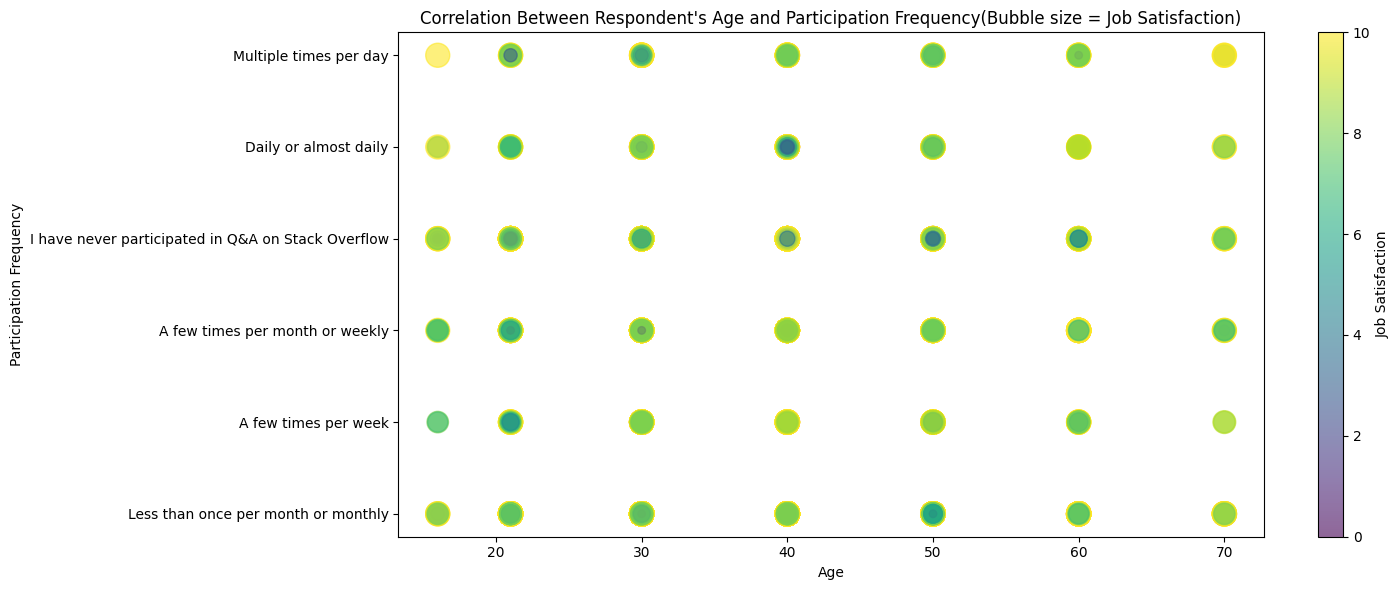

In [44]:
##Write your code here

# Mapping Age
age_mapping = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70,
    'Prefer not to say': np.nan  
}

# Apply mapping
df['AgeNum'] = df['Age'].map(age_mapping)

# Drop missing values
df_clean = df[['SOPartFreq', 'AgeNum','JobSat']].dropna()


# Plot bubble plot
plt.figure(figsize=(15, 6))
plt.scatter(
    x=df_clean['AgeNum'],
    y=df_clean['SOPartFreq'],
    s=df_clean['JobSat']*30,        # Bubble size
    alpha=0.6,
    c=df_clean['JobSat'],
)
plt.colorbar(label='Job Satisfaction')  # Show color bar for age
plt.xlabel('Age')
plt.ylabel('Participation Frequency')
plt.title("Correlation Between Respondent's Age and Participation Frequency(Bubble size = Job Satisfaction)")
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


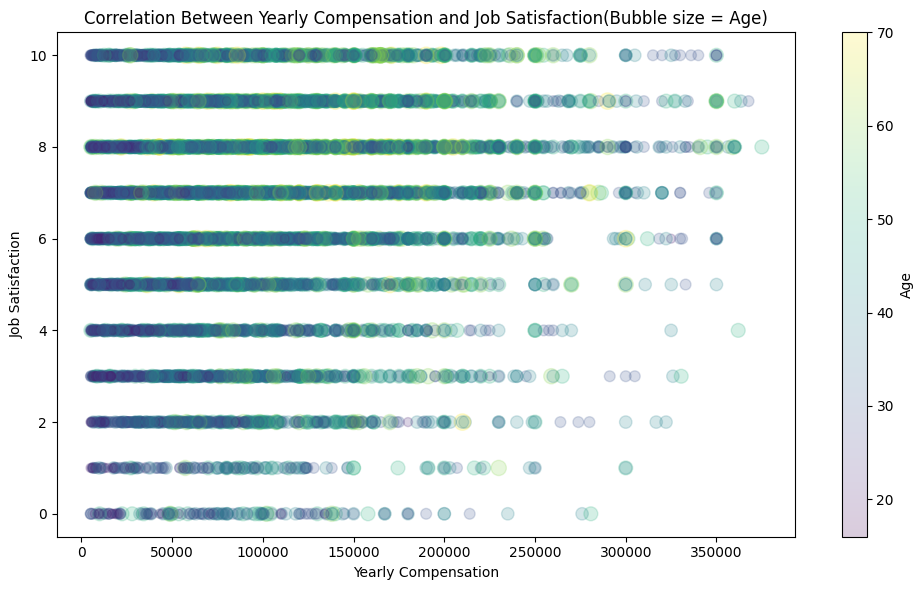

In [27]:
##Write your code here
# Drop missing values in relevant columns
df_clean = df.dropna(subset=['AgeNum', 'ConvertedCompYearly', 'JobSat'])

# Remove extreme outliers
q99 = df_clean['ConvertedCompYearly'].quantile(0.99)
df_clean = df_clean[(df_clean['ConvertedCompYearly'] >= 5000) &(df_clean['ConvertedCompYearly'] < q99)]

#Bubble Plot
plt.figure(figsize=(10, 6))
plt.scatter(
    x=df_clean['ConvertedCompYearly'],
    y=df_clean['JobSat'],
    s=df_clean['AgeNum']*2,        # Bubble size
    alpha=0.2,
    c=df_clean['AgeNum'],
)
plt.colorbar(label='Age')  # Show color bar for age
plt.xlabel('Yearly Compensation')
plt.ylabel('Job Satisfaction')
plt.title('Correlation Between Yearly Compensation and Job Satisfaction(Bubble size = Age)')
#plt.xscale('log')
plt.tight_layout()
plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



/tmp/ipykernel_300/1706428827.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_freq = df_exploded.groupby(['Age', 'LanguageHaveWorkedWith']).size().reset_index(name='Frequency')


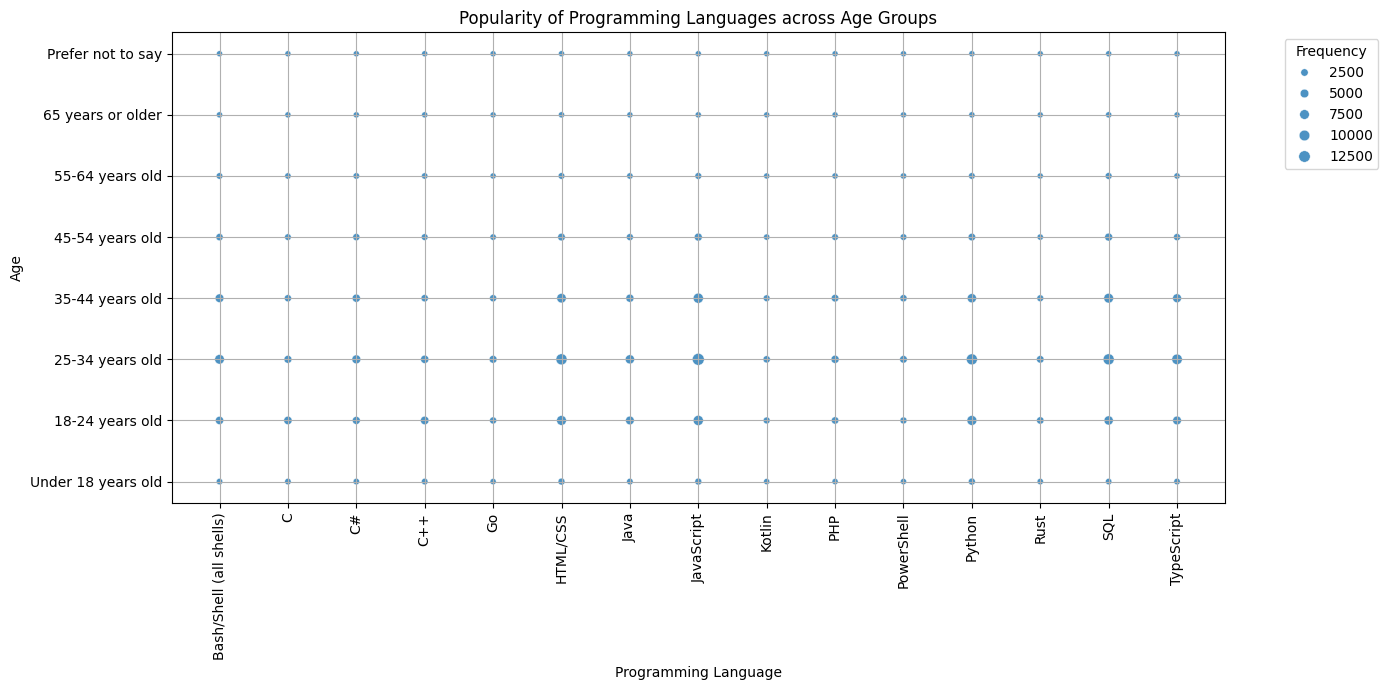

In [33]:
##Write your code here

# Drop missing values
df_lang = df[['LanguageHaveWorkedWith', 'Age']].dropna()

age_order = [
    'Prefer not to say',
    '65 years or older',
    '55-64 years old',
    '45-54 years old',
    '35-44 years old',
    '25-34 years old',
    '18-24 years old',
    'Under 18 years old',
]
df_lang['Age'] = pd.Categorical(df_lang['Age'], categories=age_order, ordered=True)

# Explode the languages
df_lang['LanguageHaveWorkedWith'] = df_lang['LanguageHaveWorkedWith'].str.split(';')
df_exploded = df_lang.explode('LanguageHaveWorkedWith')

# filter most common languages
top_langs = df_exploded['LanguageHaveWorkedWith'].value_counts().nlargest(15).index
df_exploded = df_exploded[df_exploded['LanguageHaveWorkedWith'].isin(top_langs)]

df_freq = df_exploded.groupby(['Age', 'LanguageHaveWorkedWith']).size().reset_index(name='Frequency')

# Plot  scatter plot
plt.figure(figsize=(14, 7))
sns.scatterplot(
    data=df_freq,
    x='LanguageHaveWorkedWith',
    y='Age',
    size='Frequency',
    alpha=0.8,
)
plt.xticks(rotation=90)
plt.title('Popularity of Programming Languages across Age Groups')
plt.xlabel('Programming Language')
plt.ylabel('Age')
plt.legend(title='Frequency', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


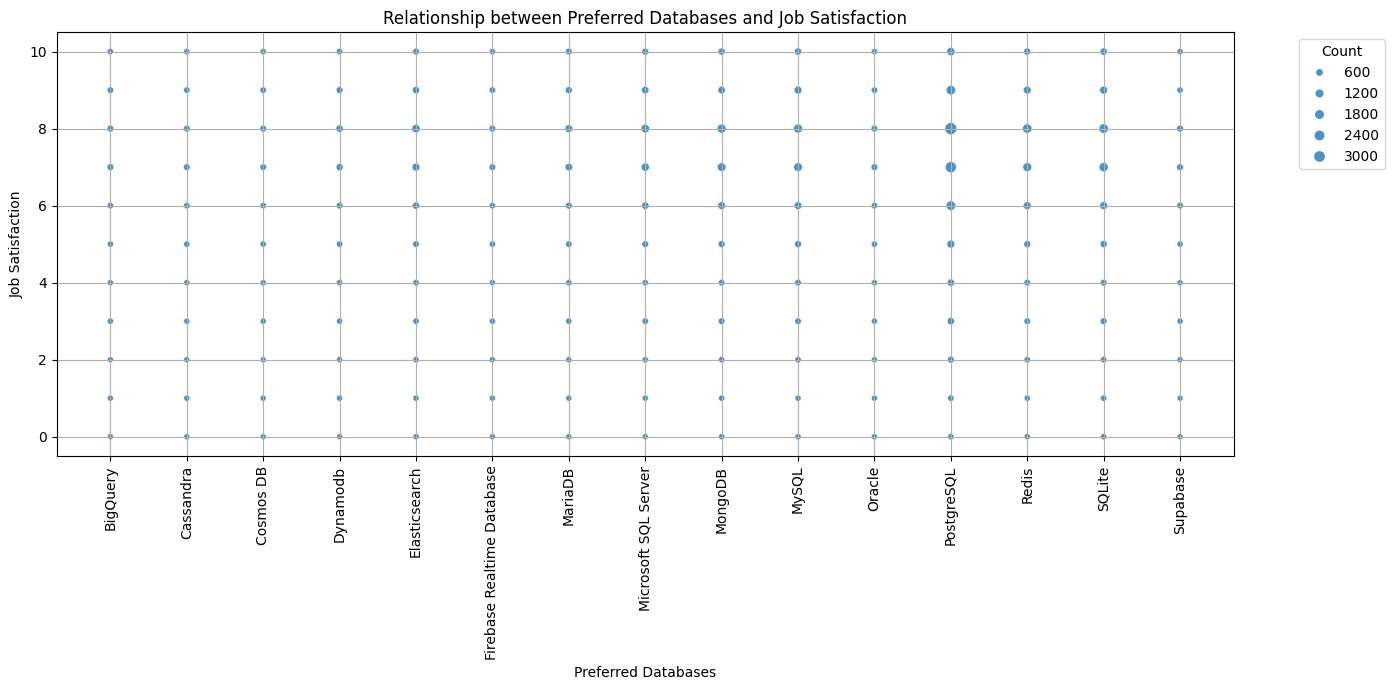

In [31]:
##Write your code here
# Drop missing values
df_clean = df[['DatabaseWantToWorkWith', 'JobSat']].dropna()

# Explode the databases
df_clean['DatabaseWantToWorkWith'] = df_clean['DatabaseWantToWorkWith'].str.split(';')
df_exploded = df_clean.explode('DatabaseWantToWorkWith')
df_exploded['DatabaseWantToWorkWith'].unique()

# filter top databases
top_db = df_exploded['DatabaseWantToWorkWith'].value_counts().nlargest(15).index
df_exploded = df_exploded[df_exploded['DatabaseWantToWorkWith'].isin(top_db)]

df_freq = df_exploded.groupby(['JobSat', 'DatabaseWantToWorkWith']).size().reset_index(name='Frequency')

# Plot  scatter plot
plt.figure(figsize=(14, 7))
sns.scatterplot(
    data=df_freq,
    x='DatabaseWantToWorkWith',
    y='JobSat',
    size='Frequency',
    alpha=0.8,
)
plt.xticks(rotation=90)
plt.title('Relationship between Preferred Databases and Job Satisfaction')
plt.xlabel('Preferred Databases')
plt.ylabel('Job Satisfaction')
plt.legend(title='Count', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


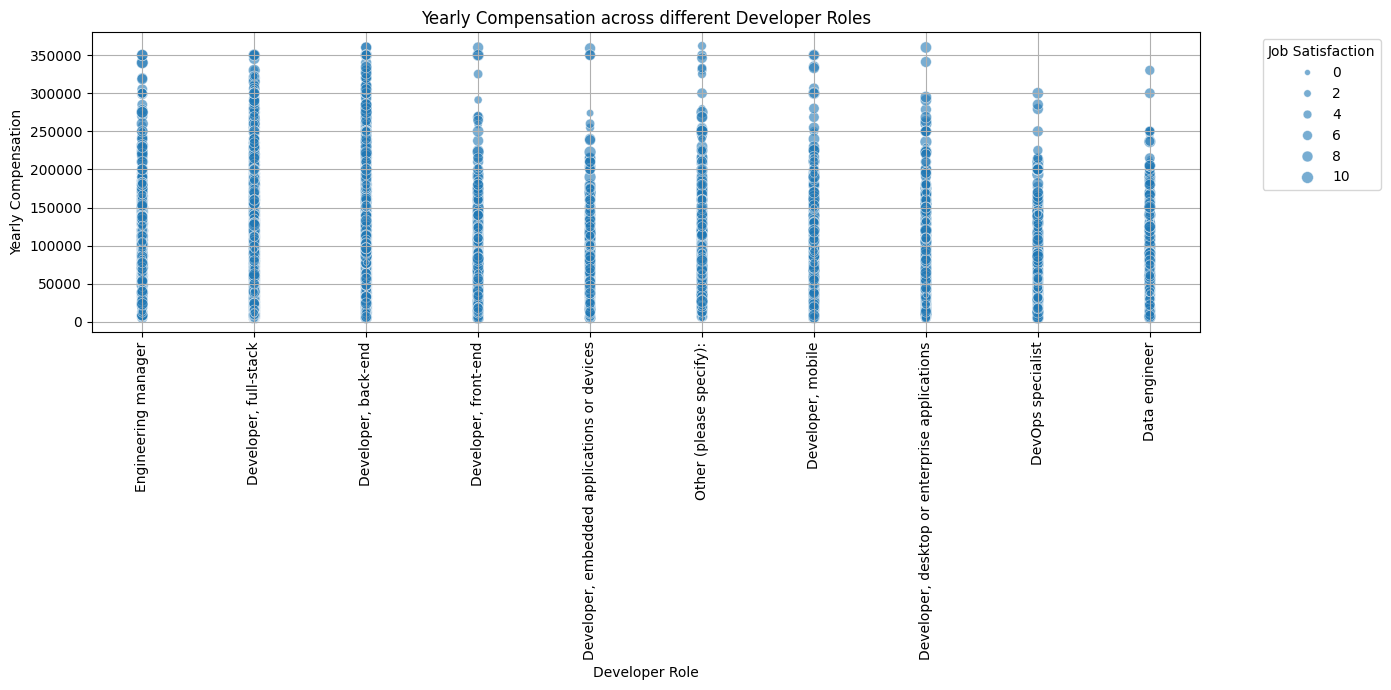

In [59]:
##Write your code here
# Drop missing values
df_clean = df[['DevType', 'ConvertedCompYearly','JobSat']].dropna()

# Remove extreme outliers
q99 = df_clean['ConvertedCompYearly'].quantile(0.99)
df_clean = df_clean[(df_clean['ConvertedCompYearly'] >= 5000) &(df_clean['ConvertedCompYearly'] < q99)]

top_devtypes = df_clean['DevType'].value_counts().nlargest(10).index
df_clean= df_clean[df_clean['DevType'].isin(top_devtypes)]


# Plot  scatter plot
plt.figure(figsize=(14, 7))
sns.scatterplot(
    data=df_clean,
    x='DevType',
    y='ConvertedCompYearly',
    size='JobSat',
    alpha=0.6,
)
plt.xticks(rotation=90)
plt.title('Yearly Compensation across different Developer Roles')
plt.xlabel('Developer Role')
plt.ylabel('Yearly Compensation')
plt.legend(title='Job Satisfaction', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


/tmp/ipykernel_300/56338090.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_freq = df_exploded.groupby(['Age', 'NEWCollabToolsHaveWorkedWith']).size().reset_index(name='Frequency')


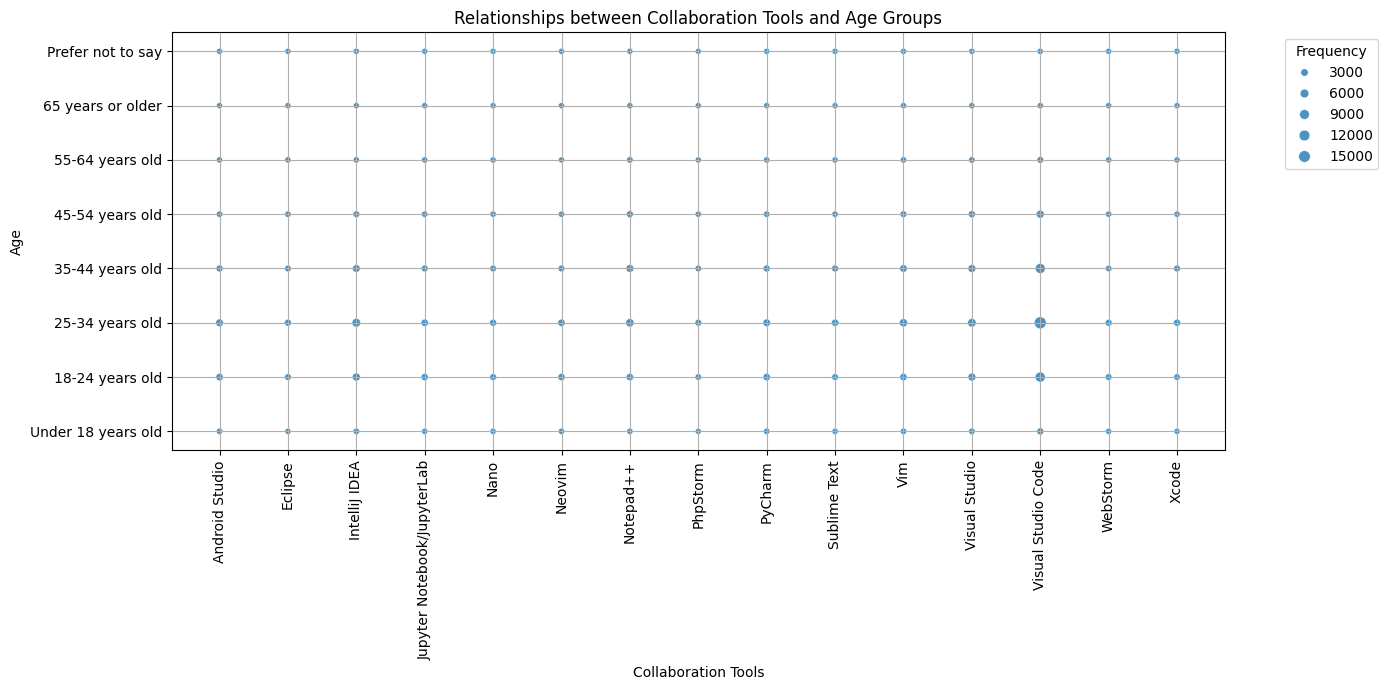

In [29]:
##Write your code here
# Drop missing values
df_clean = df[['NEWCollabToolsHaveWorkedWith', 'Age']].dropna()

age_order = [
    'Prefer not to say',
    '65 years or older',
    '55-64 years old',
    '45-54 years old',
    '35-44 years old',
    '25-34 years old',
    '18-24 years old',
    'Under 18 years old',
]
df_clean['Age'] = pd.Categorical(df_clean['Age'], categories=age_order, ordered=True)

# Explode the languages
df_clean['NEWCollabToolsHaveWorkedWith'] = df_clean['NEWCollabToolsHaveWorkedWith'].str.split(';')
df_exploded = df_clean.explode('NEWCollabToolsHaveWorkedWith')

# filter top tools
top_tools = df_exploded['NEWCollabToolsHaveWorkedWith'].value_counts().nlargest(15).index
df_exploded = df_exploded[df_exploded['NEWCollabToolsHaveWorkedWith'].isin(top_tools)]

df_freq = df_exploded.groupby(['Age', 'NEWCollabToolsHaveWorkedWith']).size().reset_index(name='Frequency')

# Plot  scatter plot
plt.figure(figsize=(14, 7))
sns.scatterplot(
    data=df_freq,
    x='NEWCollabToolsHaveWorkedWith',
    y='Age',
    size='Frequency',
    alpha=0.8,
)
plt.xticks(rotation=90)
plt.title('Relationships between Collaboration Tools and Age Groups')
plt.xlabel('Collaboration Tools')
plt.ylabel('Age')
plt.legend(title='Frequency', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



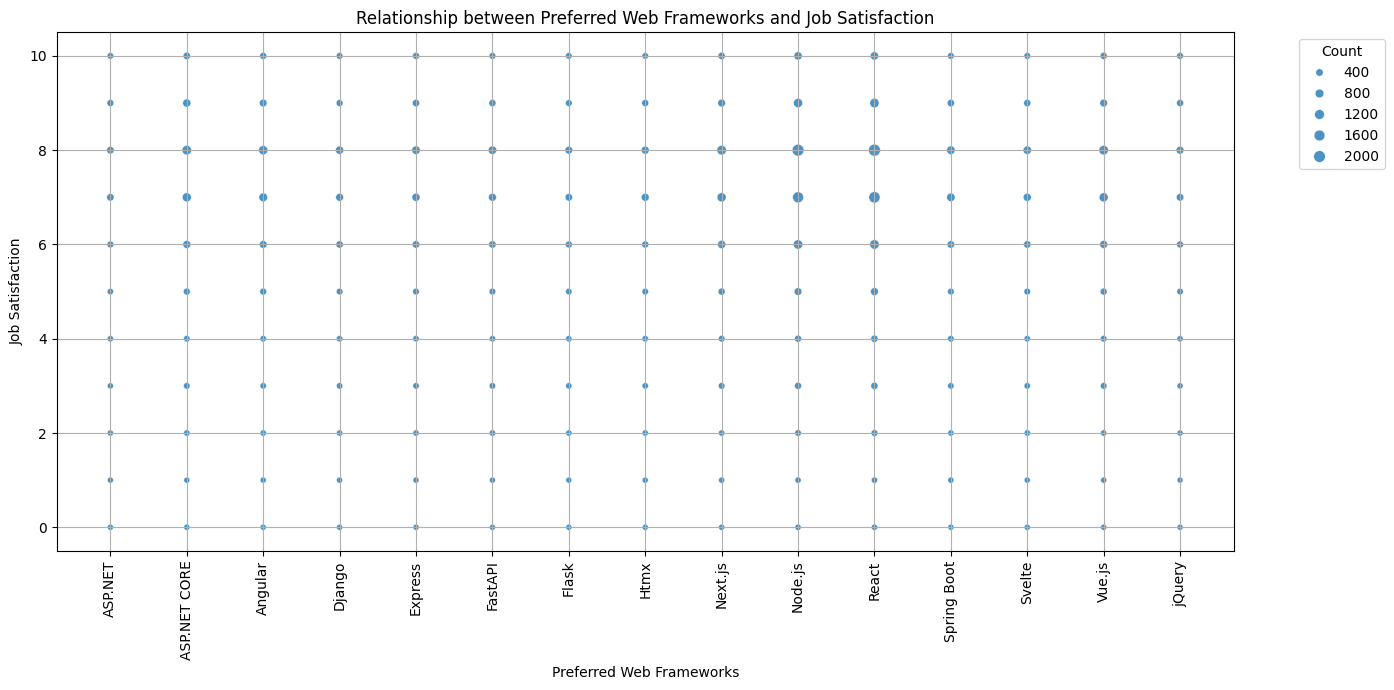

In [26]:
##Write your code here
# Drop missing values
df_clean = df[['WebframeWantToWorkWith', 'JobSat']].dropna()

# Explode the webframes
df_clean['WebframeWantToWorkWith'] = df_clean['WebframeWantToWorkWith'].str.split(';')
df_exploded = df_clean.explode('WebframeWantToWorkWith')

# filter top webframes
top_frames = df_exploded['WebframeWantToWorkWith'].value_counts().nlargest(15).index
df_exploded = df_exploded[df_exploded['WebframeWantToWorkWith'].isin(top_frames)]

df_freq = df_exploded.groupby(['JobSat', 'WebframeWantToWorkWith']).size().reset_index(name='Frequency')

# Plot  scatter plot
plt.figure(figsize=(14, 7))
sns.scatterplot(
    data=df_freq,
    x='WebframeWantToWorkWith',
    y='JobSat',
    size='Frequency',
    alpha=0.8,
)
plt.xticks(rotation=90)
plt.title('Relationship between Preferred Web Frameworks and Job Satisfaction')
plt.xlabel('Preferred Web Frameworks')
plt.ylabel('Job Satisfaction')
plt.legend(title='Count', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



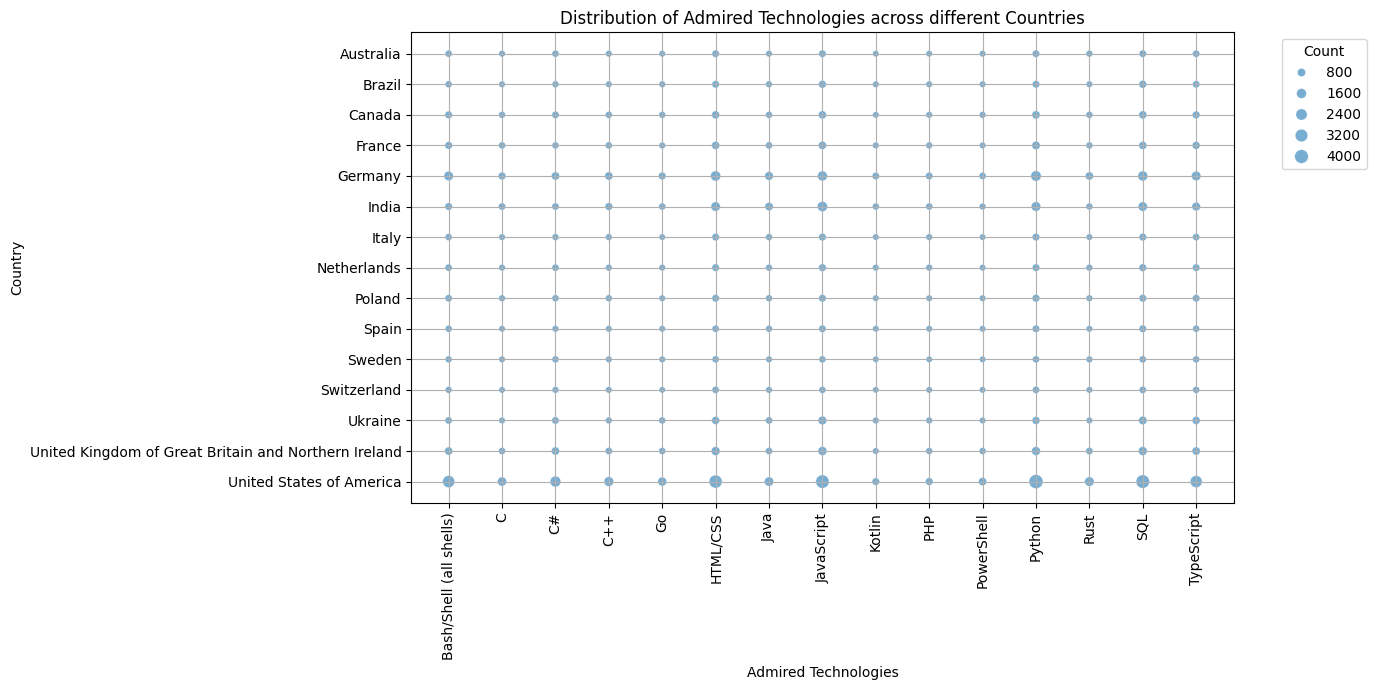

In [23]:
##Write your code here
# Drop missing values
df_clean = df[['LanguageAdmired', 'Country']].dropna()

# Explode the webframes
df_clean['LanguageAdmired'] = df_clean['LanguageAdmired'].str.split(';')
df_exploded = df_clean.explode('LanguageAdmired')

# filter top webframes
top_lang = df_exploded['LanguageAdmired'].value_counts().nlargest(15).index
df_exploded = df_exploded[df_exploded['LanguageAdmired'].isin(top_lang)]

top_countries = df_exploded['Country'].value_counts().nlargest(15).index
df_exploded = df_exploded[df_exploded['Country'].isin(top_countries)]

df_freq = df_exploded.groupby(['Country', 'LanguageAdmired']).size().reset_index(name='Frequency')

# Plot  scatter plot
plt.figure(figsize=(14, 7))
sns.scatterplot(
    data=df_freq,
    x='LanguageAdmired',
    y='Country',
    size='Frequency',
    sizes=(20, 100),
    alpha=0.6,
)
plt.xticks(rotation=90)
plt.title('Distribution of Admired Technologies across different Countries')
plt.xlabel('Admired Technologies')
plt.ylabel('Country')
plt.legend(title='Count', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
